# Advanced Parameter-Efficient Fine-Tuning (PEFT)

## Why PEFT Matters

Modern Large Language Models (LLMs) have reached staggering scales:

| Model | Parameters | VRAM (FP16) |
|-------|-----------|-------------|
| GPT-2 | 117M | ~0.5 GB |
| BERT-Large | 340M | ~1.4 GB |
| LLaMA-7B | 7B | ~14 GB |
| LLaMA-70B | 70B | ~140 GB |
| GPT-4 (est.) | ~1.7T | ~3,400 GB |

**Full fine-tuning** requires storing:
1. Model weights (e.g., 14 GB for 7B model in FP16)
2. Optimizer states (Adam: 2× weights = 28 GB)
3. Gradients (1× weights = 14 GB)
4. Activations for backprop

**Total: ~56 GB just for a 7B model!** This is infeasible on consumer hardware.

### PEFT Philosophy

PEFT methods fine-tune only a **small subset** of parameters while keeping the pretrained weights frozen:

$$\theta_{\text{PEFT}} \subset \theta_{\text{full}}, \quad |\theta_{\text{PEFT}}| \ll |\theta_{\text{full}}|$$

Key insight (Aghajanyan et al., 2020): **Pretrained models have low intrinsic dimensionality** task-specific adaptation can be expressed in a low-dimensional subspace.

### Taxonomy of PEFT Methods

```
PEFT
├── Additive Methods
│   ├── Adapter Layers (Houlsby, Pfeiffer)
│   ├── Prefix Tuning
│   ├── Prompt Tuning
│   ├── P-Tuning v1/v2
│   └── IA³
├── Reparameterization Methods
│   ├── LoRA
│   ├── QLoRA
│   ├── DoRA
│   └── Compacter
├── Selective Methods
│   ├── BitFit
│   └── Diff Pruning
└── Hybrid Methods
    ├── UniPELT
    ├── AdapterFusion
    └── MAM Adapter
```

In [1]:
# Setup and imports
# pip install peft transformers bitsandbytes accelerate datasets

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def param_efficiency(model):
    total, trainable = count_parameters(model)
    pct = 100 * trainable / total
    print(f"Total params:     {total:,}")
    print(f"Trainable params: {trainable:,}")
    print(f"Efficiency:       {pct:.4f}%")
    return pct

print("Imports ready!")

Imports ready!


## 1. LoRA: Low-Rank Adaptation

**Paper**: "LoRA: Low-Rank Adaptation of Large Language Models" (Hu et al., 2021)

### Core Idea

Weight updates during fine-tuning have **low intrinsic rank**. Instead of updating $W \in \mathbb{R}^{d \times k}$ directly, decompose the update:

$$W = W_0 + \Delta W = W_0 + BA$$

where:
- $W_0 \in \mathbb{R}^{d \times k}$ frozen pretrained weights
- $B \in \mathbb{R}^{d \times r}$ trainable, initialized to zeros
- $A \in \mathbb{R}^{r \times k}$ trainable, initialized with Gaussian noise
- $r \ll \min(d, k)$ the rank (hyperparameter, typically 4-64)

### Forward Pass

$$h = W_0 x + \frac{\alpha}{r} B A x$$

The scaling factor $\alpha/r$ controls the magnitude of updates. At initialization, $BA = 0$ so the model starts from the pretrained checkpoint.

### Parameter Count

- Full weight matrix: $d \times k$ parameters
- LoRA parameters: $r(d + k)$ parameters
- **Savings ratio**: $\frac{dk}{r(d+k)} \approx \frac{\min(d,k)}{2r}$

For GPT-3 175B with $r=4$: **trainable params reduced from 175B to ~37.7M (0.02%)!**

### Where to Apply LoRA?

Originally applied to $W_q, W_v$ in attention. Later work shows applying to all linear layers ($W_q, W_k, W_v, W_o, W_{ff1}, W_{ff2}$) improves performance.

In [2]:
# LoRA from scratch
class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=4, alpha=16, dropout=0.1):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        
        # Frozen base weight
        self.weight = nn.Parameter(torch.randn(out_features, in_features), requires_grad=False)
        self.bias = nn.Parameter(torch.zeros(out_features), requires_grad=False)
        
        # LoRA trainable weights
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)  # Gaussian init
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))          # Zero init
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # Base forward (frozen)
        base_output = nn.functional.linear(x, self.weight, self.bias)
        # LoRA forward (trainable): x -> A -> B -> scale
        lora_output = self.dropout(x) @ self.lora_A.T @ self.lora_B.T * self.scaling
        return base_output + lora_output

# Test LoRA layer
d_in, d_out, rank = 768, 768, 8
lora_layer = LoRALayer(d_in, d_out, rank=rank, alpha=16)

total_params = d_in * d_out  # full weight
lora_params = rank * (d_in + d_out)  # A + B
print(f"Full weight params: {total_params:,}")
print(f"LoRA params:        {lora_params:,}")
print(f"Reduction:          {total_params/lora_params:.1f}x fewer trainable params")

x = torch.randn(2, 10, d_in)
out = lora_layer(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {out.shape}")

Full weight params: 589,824
LoRA params:        12,288
Reduction:          48.0x fewer trainable params

Input shape:  torch.Size([2, 10, 768])
Output shape: torch.Size([2, 10, 768])


In [3]:
# LoRA with HuggingFace PEFT library
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

# Load base model
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Before LoRA:")
param_efficiency(model)

# Configure LoRA
lora_config = LoraConfig(
    r=8,                          # rank
    lora_alpha=32,                # scaling alpha
    target_modules=["query", "value"],  # which modules to adapt
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS    # sequence classification
)

# Apply LoRA
peft_model = get_peft_model(model, lora_config)

print("\nAfter LoRA:")
param_efficiency(peft_model)

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Before LoRA:
Total params:     109,483,778
Trainable params: 109,483,778
Efficiency:       100.0000%

After LoRA:
Total params:     109,780,228
Trainable params: 296,450
Efficiency:       0.2700%


0.2700395193203643

## 2. QLoRA: Quantized LoRA

**Paper**: "QLoRA: Efficient Finetuning of Quantized LLMs" (Dettmers et al., 2023)

QLoRA enables fine-tuning 65B parameter models on a single 48GB GPU a 3× reduction vs standard LoRA.

### Three Key Innovations

#### 1. NF4 (NormalFloat4) Quantization

Standard 4-bit quantization has uniform bin spacing. NF4 uses **information-theoretically optimal** quantization for normally distributed weights:

$$\text{NF4} = \{q_i\}_{i=0}^{15} \text{ where } q_i = \Phi^{-1}\left(\frac{i + 0.5}{16}\right)$$

$\Phi^{-1}$ is the inverse normal CDF. The quantization levels are the percentiles of the standard normal, giving equal-probability bins.

#### 2. Double Quantization

Quantizing the quantization constants themselves! NF4 uses blockwise quantization with scaling factors $c_1$. QLoRA quantizes these scaling factors with FP8:

$$\text{bits/param} = 4 + \frac{32}{64} = 4.5 \rightarrow 4 + \frac{8}{64} = 4.125 \text{ bits/param}$$

#### 3. Paged Optimizers

Uses NVIDIA's unified memory to automatically page optimizer states between GPU and CPU RAM during memory spikes, preventing OOM errors.

### QLoRA Forward Pass

$$Y = X W_{\text{NF4}}^{\text{dequant}} + X L_1 L_2$$

The base model runs in NF4 (dequantized to BF16 for compute), while LoRA adapters stay in BF16.

In [4]:
# QLoRA configuration
from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import prepare_model_for_kbit_training

# 4-bit quantization config (NF4 + double quantization)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",           # NormalFloat4
    bnb_4bit_compute_dtype=torch.bfloat16,  # Compute in BF16
    bnb_4bit_use_double_quant=True,      # Double quantization
)

print("BitsAndBytes config:")
print(f"  Quantization: 4-bit NF4")
print(f"  Double quantization: Enabled")
print(f"  Compute dtype: BFloat16")

# Load quantized model (commented to avoid downloading)
# model = AutoModelForCausalLM.from_pretrained(
#     "meta-llama/Llama-2-7b-hf",
#     quantization_config=bnb_config,
#     device_map="auto"
# )
# model = prepare_model_for_kbit_training(model)

# LoRA config for causal LM
qlora_config = LoraConfig(
    r=64,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],  # All linear layers
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Memory comparison
memory_fp16 = 7e9 * 2 / 1e9   # 7B params * 2 bytes
memory_nf4  = 7e9 * 0.5 / 1e9  # 7B params * 0.5 bytes (4-bit)
print(f"\nMemory comparison for 7B model:")
print(f"  FP16:  {memory_fp16:.1f} GB")
print(f"  NF4:   {memory_nf4:.1f} GB")
print(f"  Ratio: {memory_fp16/memory_nf4:.1f}x reduction")

BitsAndBytes config:
  Quantization: 4-bit NF4
  Double quantization: Enabled
  Compute dtype: BFloat16

Memory comparison for 7B model:
  FP16:  14.0 GB
  NF4:   3.5 GB
  Ratio: 4.0x reduction


## 3. DoRA: Weight-Decomposed Low-Rank Adaptation

**Paper**: "DoRA: Weight-Decomposed Low-Rank Adaptation" (Liu et al., 2024)

### Motivation

LoRA's weight updates have a coupled magnitude-direction pattern that differs from full fine-tuning. DoRA decouples these two components explicitly.

### Weight Decomposition

Any matrix can be decomposed into **magnitude** $m$ and **direction** $V$:

$$W = m \cdot \underbrace{\frac{W}{\|W\|_c}}_{\text{unit matrix } V}$$

where $\|W\|_c$ is the column-wise norm and $m \in \mathbb{R}^{1 \times k}$.

### DoRA Update Rule

$$W_{\text{DoRA}} = \underbrace{m}_{\text{trainable}} \cdot \frac{\overbrace{V}^{\text{frozen}} + \overbrace{\Delta V}^{\text{LoRA}}}{\|V + \Delta V\|_c}$$

where $\Delta V = BA$ is the standard LoRA update.

### Key Properties
- **Magnitude** $m$: directly trainable scalar per column
- **Direction** update: uses LoRA (efficient, low-rank)
- At initialization: $\Delta V = 0$, so $m = \|W_0\|_c$, recovering the pretrained model
- DoRA consistently outperforms LoRA across tasks with **same parameter count**

In [5]:
# DoRA from scratch
class DoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=4, alpha=16):
        super().__init__()
        self.rank = rank
        self.scaling = alpha / rank
        
        # Frozen base weight (direction V)
        self.weight = nn.Parameter(torch.randn(out_features, in_features), requires_grad=False)
        
        # Trainable magnitude per column
        col_norms = self.weight.norm(p=2, dim=0, keepdim=True)  # (1, in_features)
        self.magnitude = nn.Parameter(col_norms)
        
        # LoRA for direction update
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        
    def forward(self, x):
        # Compute updated direction
        delta_V = self.lora_B @ self.lora_A * self.scaling  # LoRA update
        V_new = self.weight + delta_V                        # V + ΔV
        
        # Normalize direction (column-wise)
        V_norm = V_new.norm(p=2, dim=0, keepdim=True)       # (1, in_features)
        V_unit = V_new / (V_norm + 1e-8)                    # unit direction
        
        # Combine with magnitude
        W_dora = self.magnitude * V_unit
        
        return x @ W_dora.T

# Test DoRA
dora = DoRALayer(768, 768, rank=8)
x = torch.randn(2, 10, 768)
out = dora(x)

dora_trainable = sum(p.numel() for p in dora.parameters() if p.requires_grad)
print(f"DoRA trainable params: {dora_trainable:,}")
print(f"  - Magnitude: {dora.magnitude.numel():,}")
print(f"  - LoRA A:    {dora.lora_A.numel():,}")
print(f"  - LoRA B:    {dora.lora_B.numel():,}")
print(f"Output shape: {out.shape}")

DoRA trainable params: 13,056
  - Magnitude: 768
  - LoRA A:    6,144
  - LoRA B:    6,144
Output shape: torch.Size([2, 10, 768])


## 4. Prefix Tuning

**Paper**: "Prefix-Tuning: Optimizing Continuous Prompts for Generation" (Li & Liang, 2021)

### Concept

Instead of fine-tuning model weights, prepend **trainable continuous vectors** to the key and value matrices in every attention layer.

### Architecture

For each transformer layer $i$, the modified attention is:

$$\text{Attention}(Q_i, [P^K_i; K_i], [P^V_i; V_i])$$

where:
- $P^K_i \in \mathbb{R}^{l \times d}$ trainable prefix for keys
- $P^V_i \in \mathbb{R}^{l \times d}$ trainable prefix for values
- $l$ prefix length (hyperparameter, typically 10-200)
- $[;]$ concatenation

### Reparameterization Trick

Direct optimization of $P_\theta$ is unstable. Instead, prefix embeddings are generated through a small MLP:

$$P_\theta = \text{MLP}_\theta(P'_\theta)$$

where $P'_\theta$ is a smaller embedding matrix. The MLP is discarded after training.

### Trainable Parameters

$$|\theta_{\text{prefix}}| = 2 \times l \times L \times d$$

where $L$ is the number of layers. For GPT-2 with $l=10$: only **0.1%** of parameters.

In [6]:
# Prefix Tuning from scratch
class PrefixTuning(nn.Module):
    def __init__(self, num_layers, num_heads, d_model, prefix_length=10, prefix_hidden=512):
        super().__init__()
        self.prefix_length = prefix_length
        self.num_layers = num_layers
        self.d_model = d_model
        
        # Reparameterization: small embedding -> MLP -> prefix
        self.prefix_embedding = nn.Embedding(prefix_length, d_model)
        self.prefix_mlp = nn.Sequential(
            nn.Linear(d_model, prefix_hidden),
            nn.Tanh(),
            nn.Linear(prefix_hidden, num_layers * 2 * d_model)  # K and V for each layer
        )
        
    def forward(self, batch_size):
        # Generate prefix tokens
        prefix_idx = torch.arange(self.prefix_length).unsqueeze(0).expand(batch_size, -1)
        prefix_emb = self.prefix_embedding(prefix_idx)  # (B, L, d_model)
        
        # Transform through MLP
        prefix = self.prefix_mlp(prefix_emb)  # (B, L, num_layers * 2 * d_model)
        
        # Reshape to (num_layers, 2, B, L, d_model)
        B, L, _ = prefix.shape
        prefix = prefix.view(B, L, self.num_layers, 2, self.d_model)
        prefix = prefix.permute(2, 3, 0, 1, 4)  # (num_layers, 2, B, L, d_model)
        
        return prefix  # prefix[i, 0] = prefix keys for layer i, prefix[i, 1] = prefix values

# Example with GPT-2 dimensions
prefix_tuner = PrefixTuning(num_layers=12, num_heads=12, d_model=768, prefix_length=20)
batch_size = 4
prefix = prefix_tuner(batch_size)

total_p, train_p = count_parameters(prefix_tuner)
print(f"Prefix Tuning (l=20, GPT-2):")
print(f"  Prefix shape:      {prefix.shape}")  # (layers, K/V, batch, prefix_len, d)
print(f"  Trainable params:  {train_p:,}")
print(f"  GPT-2 total:       ~117,000,000")
print(f"  Overhead:          {100*train_p/117e6:.2f}%")

Prefix Tuning (l=20, GPT-2):
  Prefix shape:      torch.Size([12, 2, 4, 20, 768])
  Trainable params:  9,864,704
  GPT-2 total:       ~117,000,000
  Overhead:          8.43%


## 5. Prompt Tuning

**Paper**: "The Power of Scale for Parameter-Efficient Prompt Tuning" (Lester et al., 2021)

### Simplification of Prefix Tuning

Prompt Tuning is a simplified version: instead of prefixing every layer's key/value, only prepend trainable tokens to the **input embedding layer**.

$$T = [t_1, t_2, \ldots, t_k] \in \mathbb{R}^{k \times d}$$

The model receives: $[T; X_e]$ where $X_e$ are the input token embeddings.

### Comparison: Prefix vs Prompt Tuning

| Aspect | Prefix Tuning | Prompt Tuning |
|--------|--------------|---------------|
| Where applied | All layers (K, V) | Input layer only |
| Reparameterization | MLP needed | Direct |
| Parameters | $2lLd$ | $kd$ |
| Typical params % | ~0.1% | ~0.01% |

### Scaling Behavior

Lester et al. showed that **at T5-XXL scale (11B params), prompt tuning matches full fine-tuning performance** the gap narrows dramatically with model scale.

In [7]:
# Prompt Tuning
class SoftPromptTuning(nn.Module):
    def __init__(self, vocab_size, d_model, num_soft_tokens=20):
        super().__init__()
        self.num_soft_tokens = num_soft_tokens
        
        # Frozen token embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.token_embedding.weight.requires_grad = False
        
        # Trainable soft prompt tokens
        self.soft_prompt = nn.Parameter(torch.randn(num_soft_tokens, d_model) * 0.02)
        
    def forward(self, input_ids):
        # Get token embeddings
        token_embeds = self.token_embedding(input_ids)  # (B, seq_len, d)
        
        # Expand soft prompt for batch
        batch_size = input_ids.shape[0]
        soft_tokens = self.soft_prompt.unsqueeze(0).expand(batch_size, -1, -1)  # (B, k, d)
        
        # Prepend soft tokens to input
        inputs_embeds = torch.cat([soft_tokens, token_embeds], dim=1)  # (B, k+seq_len, d)
        return inputs_embeds

# Using HuggingFace PEFT for Prompt Tuning
from peft import PromptTuningConfig, PromptTuningInit

prompt_config = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    prompt_tuning_init=PromptTuningInit.TEXT,       # Initialize from text
    num_virtual_tokens=20,
    prompt_tuning_init_text="Classify the sentiment of this text: ",
    tokenizer_name_or_path="gpt2"
)

print("Soft Prompt Tuning:")
spt = SoftPromptTuning(vocab_size=30000, d_model=768, num_soft_tokens=20)
trainable = sum(p.numel() for p in spt.parameters() if p.requires_grad)
print(f"  Trainable params: {trainable:,} (just the soft prompt!)")
print(f"  Per token: {768} dimensions")
print(f"  Total: 20 tokens × 768 dims = {20*768:,}")

Soft Prompt Tuning:


  Trainable params: 15,360 (just the soft prompt!)
  Per token: 768 dimensions
  Total: 20 tokens × 768 dims = 15,360


## 6. P-Tuning v1 and v2

### P-Tuning v1 (GPT Understands, Too)
**Paper**: Liu et al., 2021

P-Tuning v1 addresses the problem that directly optimizing discrete prompts is non-differentiable. Instead:

1. **Continuous prompt tokens**: Replace discrete tokens with trainable embeddings $h_i$
2. **Context-aware via LSTM**: A small LSTM/MLP makes prompt tokens depend on each other:

$$[h_0, \ldots, h_m] = \text{MLP}([e(p_0), \ldots, e(p_m)])$$

The LSTM ensures coherent prompt representations (unlike independent token embeddings).

**Key insight**: Prompt tokens can be placed **anywhere** in the input before, after, or interspersed with real tokens. Template: `[P1] Context [P2] Question: [P3] Answer:`

### P-Tuning v2
**Paper**: "P-Tuning v2: Prompt Tuning Can Be Comparable to Fine-tuning" (Liu et al., 2022)

P-Tuning v2 = Prefix Tuning applied at **every transformer layer** (not just input):

$$\text{Layer } l: \text{Attention}(Q_l, [P^K_l; K_l], [P^V_l; V_l])$$

This provides more capacity and enables:
- Comparable performance to fine-tuning on **small models** (300M-10B)
- Works for **hard NLP tasks** (NER, relation extraction) unlike v1

In [8]:
# P-Tuning v1: LSTM-based prompt encoder
class PTuningPromptEncoder(nn.Module):
    def __init__(self, num_virtual_tokens, embedding_dim, hidden_size=128):
        super().__init__()
        self.num_tokens = num_virtual_tokens
        
        # Learnable token embeddings (random init)
        self.embedding = nn.Embedding(num_virtual_tokens, embedding_dim)
        
        # LSTM encoder for context-aware prompts
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        
        # Project back to embedding dim
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, embedding_dim)
        )
        
    def forward(self):
        indices = torch.arange(self.num_tokens)   # (num_tokens,)
        token_embeds = self.embedding(indices).unsqueeze(0)  # (1, num_tokens, d)
        lstm_out, _ = self.lstm(token_embeds)     # (1, num_tokens, 2*hidden)
        prompt_embeds = self.mlp(lstm_out)        # (1, num_tokens, d)
        return prompt_embeds.squeeze(0)           # (num_tokens, d)

# P-Tuning v2 via HuggingFace PEFT
from peft import PrefixTuningConfig

# P-Tuning v2 = Prefix Tuning at all layers
p_tuning_v2_config = PrefixTuningConfig(
    task_type=TaskType.TOKEN_CLS,
    num_virtual_tokens=20,
    encoder_hidden_size=128,   # reparameterization MLP size
    prefix_projection=True     # use MLP reparameterization
)

# Demo P-Tuning v1 encoder
encoder = PTuningPromptEncoder(num_virtual_tokens=10, embedding_dim=768)
prompts = encoder()
print(f"P-Tuning v1 encoder output: {prompts.shape}")
print(f"Trainable params: {sum(p.numel() for p in encoder.parameters()):,}")

P-Tuning v1 encoder output: torch.Size([10, 768])
Trainable params: 1,454,464


## 7. Adapter Layers

**Paper**: "Parameter-Efficient Transfer Learning for NLP" (Houlsby et al., 2019)

### Architecture

Adapter layers are small bottleneck modules inserted **inside** each transformer layer:

$$h \leftarrow h + f(hW_{\text{down}})W_{\text{up}}$$

where:
- $W_{\text{down}} \in \mathbb{R}^{d \times r}$ down-projection
- $W_{\text{up}} \in \mathbb{R}^{r \times d}$ up-projection
- $f$ non-linearity (GELU or ReLU)
- Residual connection ensures near-identity at init

**Parameters per adapter**: $2rd + r + d \approx 2rd$ (two small weight matrices)

### Houlsby vs Pfeiffer Placement

```
Houlsby (2019):              Pfeiffer (2020):
  Multi-Head Attention           Multi-Head Attention
  [Adapter]                      LayerNorm
  LayerNorm                      FFN
  Feed-Forward Network           [Adapter]         ← only here
  [Adapter]                      LayerNorm
  LayerNorm
```

Pfeiffer placement: 1 adapter per layer (vs 2 for Houlsby), similar performance at half the params.

### Inference Efficiency Issue

Unlike LoRA, adapters **cannot be merged** into the base model they require extra sequential compute at inference time, adding ~5-20% latency.

In [9]:
# Adapter Layer implementation
class AdapterLayer(nn.Module):
    def __init__(self, d_model, bottleneck_dim, dropout=0.1, init_scale=1e-3):
        super().__init__()
        self.down_proj = nn.Linear(d_model, bottleneck_dim)
        self.up_proj   = nn.Linear(bottleneck_dim, d_model)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)
        
        # Near-zero init for residual branch
        nn.init.normal_(self.down_proj.weight, std=init_scale)
        nn.init.normal_(self.up_proj.weight, std=init_scale)
        nn.init.zeros_(self.down_proj.bias)
        nn.init.zeros_(self.up_proj.bias)
        
    def forward(self, x):
        residual = x
        x = self.layer_norm(x)
        x = self.down_proj(x)      # d -> r
        x = self.activation(x)
        x = self.dropout(x)
        x = self.up_proj(x)        # r -> d
        return x + residual        # residual connection


class TransformerLayerWithAdapter(nn.Module):
    """Pfeiffer placement: adapter after FFN only."""
    def __init__(self, d_model=768, n_heads=12, ffn_dim=3072, bottleneck=64):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Linear(ffn_dim, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.adapter = AdapterLayer(d_model, bottleneck)  # Only trainable part
        
        # Freeze everything except adapter
        for param in list(self.attn.parameters()) + list(self.ffn.parameters()):
            param.requires_grad = False
            
    def forward(self, x):
        x = self.norm1(x + self.attn(x, x, x)[0])
        x = self.norm2(x + self.ffn(x))
        x = self.adapter(x)   # Pfeiffer: after FFN+norm
        return x

layer = TransformerLayerWithAdapter()
total, trainable = count_parameters(layer)
print(f"Transformer layer with Pfeiffer adapter:")
print(f"  Total:     {total:,}")
print(f"  Trainable: {trainable:,} ({100*trainable/total:.2f}%)")

Transformer layer with Pfeiffer adapter:
  Total:     7,188,544
  Trainable: 103,744 (1.44%)


## 8. IA³: Infused Adapter by Inhibiting and Amplifying Inner Activations

**Paper**: "Few-Shot Parameter-Efficient Fine-Tuning is Better and Cheaper than In-Context Learning" (Liu et al., 2022)

### Core Idea

IA³ is extremely lightweight: learn **element-wise rescaling vectors** that modulate activations.

$$h = (l_k \odot K^T)^T s(h) \quad \text{(keys)}$$
$$h = (l_v \odot V^T)^T \quad \text{(values)}$$  
$$h = l_{ff} \odot \gamma(W_1 h) \quad \text{(FFN intermediate)}$$

where $l_k, l_v, l_{ff}$ are learned vectors with the same dimension as the activation being scaled.

### Remarkably Few Parameters

Only **3 vectors per transformer layer**:
- $l_k \in \mathbb{R}^{d_k}$ key scaling
- $l_v \in \mathbb{R}^{d_v}$ value scaling  
- $l_{ff} \in \mathbb{R}^{d_{ff}}$ FFN scaling

For T5-XL (3B params): IA³ uses only **~0.01%** of parameters, yet achieves strong few-shot performance.

### Initialization

All $l$ vectors initialized to **ones** the model starts as an exact copy of the pretrained model.

In [10]:
# IA³ implementation
class IA3AttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        d_head = d_model // n_heads
        self.n_heads = n_heads
        self.d_head = d_head
        
        # Frozen weights
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.W1 = nn.Linear(d_model, d_ff, bias=False)
        self.W2 = nn.Linear(d_ff, d_model, bias=False)
        
        for p in self.parameters():
            p.requires_grad = False
        
        # IA³ scaling vectors (3 per layer, all trainable)
        self.l_k  = nn.Parameter(torch.ones(d_model))   # key scaling
        self.l_v  = nn.Parameter(torch.ones(d_model))   # value scaling
        self.l_ff = nn.Parameter(torch.ones(d_ff))      # FFN scaling
        
    def forward(self, x):
        B, T, D = x.shape
        
        Q = self.Wq(x)
        K = self.Wk(x) * self.l_k  # IA³: scale keys
        V = self.Wv(x) * self.l_v  # IA³: scale values
        
        # Simplified attention
        scale = self.d_head ** -0.5
        attn = torch.softmax(Q @ K.transpose(-2,-1) * scale, dim=-1)
        out = attn @ V
        out = self.Wo(out)
        
        # FFN with IA³ scaling
        ff = torch.relu(self.W1(x)) * self.l_ff  # IA³: scale FFN intermediate
        ff = self.W2(ff)
        
        return out + ff

ia3_layer = IA3AttentionLayer(d_model=768, n_heads=12, d_ff=3072)
total, trainable = count_parameters(ia3_layer)
print(f"IA³ Layer:")
print(f"  l_k params:  {ia3_layer.l_k.numel():,}")
print(f"  l_v params:  {ia3_layer.l_v.numel():,}")
print(f"  l_ff params: {ia3_layer.l_ff.numel():,}")
print(f"  Total trainable: {trainable:,} ({100*trainable/total:.4f}% of layer)")

IA³ Layer:
  l_k params:  768
  l_v params:  768
  l_ff params: 3,072
  Total trainable: 4,608 (0.0651% of layer)


## 9. BitFit: Bias-Term Fine-Tuning

**Paper**: "BitFit: Simple Parameter-efficient Fine-tuning for Transformer-based Masked Language-models" (Ben-Zaken et al., 2021)

The simplest possible PEFT: **only update bias terms**.

$$\theta_{\text{BitFit}} = \{b_l^{\text{attn}}, b_l^{\text{ffn}}, b_l^{\text{ln}} \}_{l=1}^{L}$$

Bias terms represent only **0.08-0.09%** of BERT parameters yet achieve competitive results on GLUE benchmarks.

**Insight**: The query bias $b^q$ is especially important it controls what patterns each attention head seeks, while the key/value transformations capture the structure of inputs.

In [11]:
# BitFit: freeze all weights, train only biases
from transformers import AutoModelForSequenceClassification

def apply_bitfit(model):
    """Freeze all parameters except biases."""
    for name, param in model.named_parameters():
        if 'bias' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True
    return model

# Demo
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
total_before, train_before = count_parameters(model)

model = apply_bitfit(model)
total_after, train_after = count_parameters(model)

print("BitFit Analysis:")
print(f"  Total params:           {total_before:,}")
print(f"  Trainable (full FT):    {train_before:,} (100%)")
print(f"  Trainable (BitFit):     {train_after:,} ({100*train_after/total_before:.3f}%)")

# Which bias terms exist?
bias_names = [n for n, p in model.named_parameters() if p.requires_grad]
print(f"\n  Bias terms: {len(bias_names)} total")
for n in bias_names[:8]:
    print(f"    {n}")
print(f"    ... and {len(bias_names)-8} more")

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BitFit Analysis:
  Total params:           109,483,778
  Trainable (full FT):    109,483,778 (100%)
  Trainable (BitFit):     102,914 (0.094%)

  Bias terms: 99 total
    bert.embeddings.LayerNorm.bias
    bert.encoder.layer.0.attention.self.query.bias
    bert.encoder.layer.0.attention.self.key.bias
    bert.encoder.layer.0.attention.self.value.bias
    bert.encoder.layer.0.attention.output.dense.bias
    bert.encoder.layer.0.attention.output.LayerNorm.bias
    bert.encoder.layer.0.intermediate.dense.bias
    bert.encoder.layer.0.output.dense.bias
    ... and 91 more


## 10. Advanced Variants and Compositions

### UniPELT (2022)
Combines **LoRA + Prefix Tuning + Adapter** with learned gating:

$$h = \mathcal{G}_{\text{LoRA}} \cdot h_{\text{LoRA}} + \mathcal{G}_{\text{Prefix}} \cdot h_{\text{Prefix}} + \mathcal{G}_{\text{Adapter}} \cdot h_{\text{Adapter}}$$

Gates $\mathcal{G} \in (0,1)$ are task-learned, allowing the model to select which PEFT components are useful.

### AdapterFusion (2021)
Train task-specific adapters, then learn to **compose** multiple adapters via attention:

$$h = \text{Softmax}(Q K^T / \sqrt{d}) \cdot V \quad \text{(attention over adapter outputs)}$$

Stage 1: Train $N$ task adapters independently. Stage 2: Freeze adapters, learn fusion attention.

### ReLoRA (2023)
For pretraining: periodically **merge** LoRA into base weights and restart:

$$W_0 \leftarrow W_0 + BA, \quad B \leftarrow 0, A \leftarrow \text{Gaussian}$$

This allows escaping the low-rank subspace while maintaining parameter efficiency.

### S-LoRA (2023)
**Scalable serving** of thousands of LoRA adapters from a single base model:
- Store all adapters in CPU memory
- Dynamically load requested adapters to GPU
- Batch compute: $Y_i = X W_0 + X B_i A_i$ for each request $i$
- Custom CUDA kernels for batched LoRA compute

### Compacter (2021)
Uses **hypercomplex multiplication** (PHM) for adapters:
$$W = \sum_{i=1}^n A_i \otimes B_i \quad \text{(Kronecker product sum)}$$

Reduces adapter parameters by $n$× while maintaining expressiveness.

### Ladder Side-Tuning (LST, 2022)
A separate small **side network** runs in parallel with the frozen backbone:
- Side network receives features from frozen model's intermediate layers
- 10-100× parameter reduction vs fine-tuning
- Advantageous for backprop efficiency (no gradient through large backbone)

### Delta Tuning Framework (2022)
Unifies all PEFT methods under three operations:
- **Addition** (adapters, prefix): $h' = h + \delta$
- **Specification** (BitFit, diff pruning): train subset of $\theta$
- **Reparameterization** (LoRA): $\theta = \phi(\psi)$ where $\psi \ll \theta$

In [12]:
# ReLoRA: periodic merging
class ReLoRATrainer:
    def __init__(self, model, lora_config, merge_every=1000):
        from peft import get_peft_model
        self.model = get_peft_model(model, lora_config)
        self.merge_every = merge_every
        self.step = 0
        
    def train_step(self, batch):
        self.step += 1
        # ... training logic ...
        if self.step % self.merge_every == 0:
            self.merge_and_reset()
            
    def merge_and_reset(self):
        # 1. Merge LoRA into base weights
        self.model = self.model.merge_and_unload()
        # 2. Re-apply fresh LoRA
        from peft import get_peft_model, LoraConfig
        new_config = LoraConfig(r=8, lora_alpha=32, target_modules=["q_proj", "v_proj"])
        self.model = get_peft_model(self.model, new_config)
        print(f"Step {self.step}: Merged LoRA and reset!")


# Demonstrate merging LoRA into base model
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig

base = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
cfg = LoraConfig(r=8, lora_alpha=32, target_modules=["query", "value"], task_type=TaskType.SEQ_CLS)
peft_m = get_peft_model(base, cfg)

print("Before merge:")
param_efficiency(peft_m)

# Merge LoRA weights into base and remove adapters
merged = peft_m.merge_and_unload()

print("\nAfter merge (LoRA absorbed into base weights):")
param_efficiency(merged)
print("\nAll params are frozen (no PEFT overhead at inference!)")

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Before merge:
Total params:     109,780,228
Trainable params: 296,450
Efficiency:       0.2700%

After merge (LoRA absorbed into base weights):
Total params:     109,483,778
Trainable params: 1,538
Efficiency:       0.0014%

All params are frozen (no PEFT overhead at inference!)


## 11. PEFT Methods Comparison

### Comprehensive Comparison Table

| Method | Trainable % | Memory | Inference Overhead | Mergebale | Best For |
|--------|------------|--------|--------------------|-----------|----------|
| Full FT | 100% | +++++ | None | | Maximum performance |
| LoRA (r=8) | 0.1-1% | ++ | None (mergeable) | ✓ | General tasks |
| QLoRA | 0.1-1% | + | None | ✓ | Low-memory fine-tuning |
| DoRA | ~0.1% | ++ | None (mergeable) | ✓ | Outperforms LoRA |
| Prefix Tuning | ~0.1% | + | Low | ✗ | Generation tasks |
| Prompt Tuning | ~0.01% | + | Very Low | ✗ | Large models only |
| P-Tuning v2 | ~0.1% | + | Low | ✗ | NLU/structured tasks |
| Adapter (r=64) | 3-4% | ++ | Medium (~10-20%) | ✗ | Multi-task learning |
| IA³ | 0.01% | + | None (mergeable) | ✓ | Few-shot, smallest params |
| BitFit | 0.08% | + | None | ✓ | Simple, surprising baseline |
| UniPELT | ~0.3% | ++ | Medium | ✗ | Diverse tasks |

### When to Use Which Method

```
Memory constrained?                YES → QLoRA
Need zero inference overhead?      YES → LoRA/DoRA/IA³ (merge into base)
Very few labeled examples?         YES → Prompt Tuning / IA³
Serving 100s of tasks?             YES → Adapters + AdapterFusion or S-LoRA
Maximum performance?               YES → DoRA or full fine-tuning
Simple baseline?                   YES → BitFit (surprisingly strong!)
```

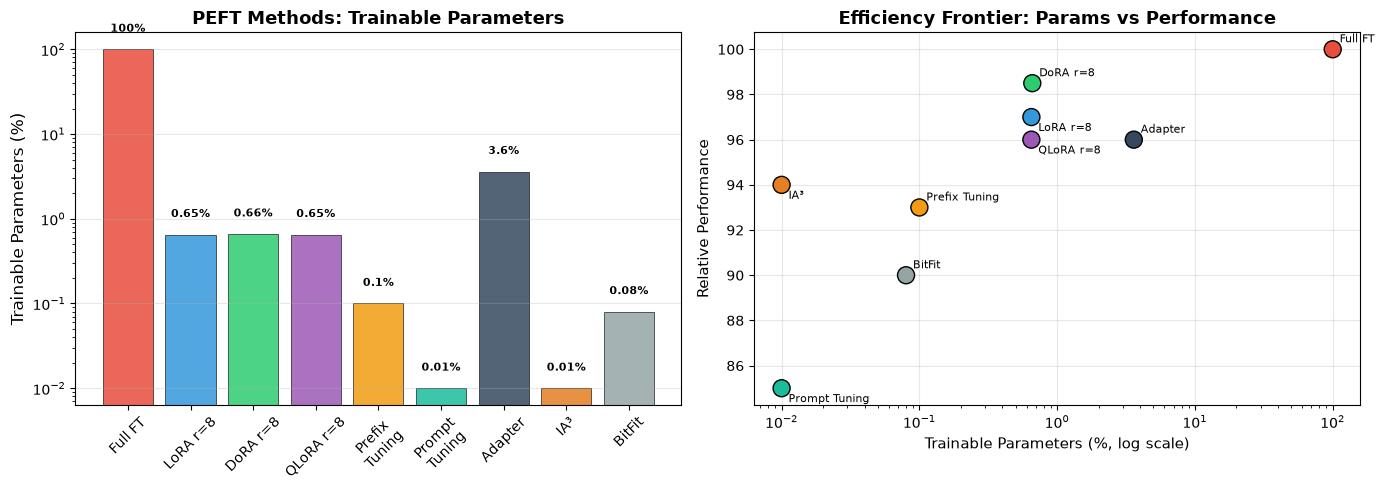

In [13]:
# Visualize PEFT parameter efficiency comparison
import matplotlib.pyplot as plt
import numpy as np

methods = ['Full FT', 'LoRA r=8', 'DoRA r=8', 'QLoRA r=8', 
           'Prefix\nTuning', 'Prompt\nTuning', 'Adapter', 'IA³', 'BitFit']
trainable_pct = [100, 0.65, 0.66, 0.65, 0.1, 0.01, 3.6, 0.01, 0.08]

# Relative performance on GLUE (approximate, 7B model scale)
performance = [100, 97, 98.5, 96, 93, 85, 96, 94, 90]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trainable parameters
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', 
          '#1abc9c', '#34495e', '#e67e22', '#95a5a6']
bars = ax1.bar(methods, trainable_pct, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Trainable Parameters (%)', fontsize=12)
ax1.set_title('PEFT Methods: Trainable Parameters', fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, trainable_pct):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5, 
             f'{val}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Efficiency frontier
ax2.scatter(trainable_pct, performance, c=colors, s=150, zorder=5, edgecolors='black')
for i, (m, x, y) in enumerate(zip(methods, trainable_pct, performance)):
    offset = (5, 5) if i % 2 == 0 else (5, -10)
    ax2.annotate(m.replace('\n', ' '), (x, y), xytext=offset, 
                 textcoords='offset points', fontsize=8)
ax2.set_xscale('log')
ax2.set_xlabel('Trainable Parameters (%, log scale)', fontsize=11)
ax2.set_ylabel('Relative Performance', fontsize=11)
ax2.set_title('Efficiency Frontier: Params vs Performance', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('peft_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Production PEFT with HuggingFace PEFT Library

In [14]:
# Complete fine-tuning pipeline with PEFT + LoRA
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset, DatasetDict
import evaluate
import numpy as np

# 1. Load model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Apply LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value", "key", "dense"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# 3. Prepare dataset
_raw = load_dataset("stanfordnlp/sst2")
dataset = DatasetDict({
    "train": _raw["train"].select(range(1000)),
    "validation": _raw["validation"].select(range(200)),
})

def tokenize(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=128)

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")

# 4. Training
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir="./lora-sst2",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-4,       # Higher LR for PEFT vs full FT
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

# trainer.train()
print("Training pipeline ready! (Uncomment trainer.train() to run)")

# 5. Save and load PEFT model
# model.save_pretrained("./lora-sst2-final")
# 
# # Load: only saves adapter weights (~MBs vs GBs for full model)
# from peft import PeftModel
# base = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# model = PeftModel.from_pretrained(base, "./lora-sst2-final")

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,680,322 || all params: 112,164,100 || trainable%: 2.3896


Training pipeline ready! (Uncomment trainer.train() to run)


## Additional Learning Resources

### Foundational Papers

| Method | Paper | Link |
|--------|-------|------|
| LoRA | "LoRA: Low-Rank Adaptation of Large Language Models" | https://arxiv.org/abs/2106.09685 |
| QLoRA | "QLoRA: Efficient Finetuning of Quantized LLMs" | https://arxiv.org/abs/2305.14314 |
| DoRA | "DoRA: Weight-Decomposed Low-Rank Adaptation" | https://arxiv.org/abs/2402.09353 |
| Prefix Tuning | "Prefix-Tuning: Optimizing Continuous Prompts" | https://arxiv.org/abs/2101.00190 |
| Prompt Tuning | "The Power of Scale for Parameter-Efficient Prompt Tuning" | https://arxiv.org/abs/2104.08691 |
| P-Tuning | "GPT Understands, Too" | https://arxiv.org/abs/2103.10385 |
| P-Tuning v2 | "P-Tuning v2: Prompt Tuning Can Be Comparable to Fine-tuning" | https://arxiv.org/abs/2110.07602 |
| Adapters | "Parameter-Efficient Transfer Learning for NLP" | https://arxiv.org/abs/1902.00751 |
| IA³ | "Few-Shot Parameter-Efficient Fine-Tuning" | https://arxiv.org/abs/2205.05638 |
| BitFit | "BitFit: Simple Parameter-efficient Fine-tuning" | https://arxiv.org/abs/2106.10199 |
| ReLoRA | "ReLoRA: High-Rank Training Through Low-Rank Updates" | https://arxiv.org/abs/2307.05695 |
| S-LoRA | "S-LoRA: Serving Thousands of Concurrent LoRA Adapters" | https://arxiv.org/abs/2311.03285 |

### Libraries and Tools
- **HuggingFace PEFT**: https://github.com/huggingface/peft
- **bitsandbytes**: https://github.com/TimDettmers/bitsandbytes
- **Axolotl** (LLM fine-tuning framework): https://github.com/OpenAccess-AI-Collective/axolotl
- **LLaMA-Factory**: https://github.com/hiyouga/LLaMA-Factory

### Surveys and Tutorials
- "Delta Tuning: A Comprehensive Study of Parameter Efficient Methods" - https://arxiv.org/abs/2203.06904
- "Scaling Down to Scale Up: A Guide to Parameter-Efficient Fine-Tuning" - https://arxiv.org/abs/2303.15647
- HuggingFace PEFT documentation: https://huggingface.co/docs/peft
- Sebastian Raschka's PEFT article: https://magazine.sebastianraschka.com/p/understanding-parameter-efficient

### Benchmarks
- GLUE/SuperGLUE: https://gluebenchmark.com/
- MTEB (for embeddings): https://huggingface.co/spaces/mteb/leaderboard